# 03. Budget Optimization

Optimize a fixed 13-week media budget and compare it with the current media mix.

In [36]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pymc_marketing.mmm.multidimensional import (
    MMM,
    MultiDimensionalBudgetOptimizerWrapper,
)

ROOT = next(
    p for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / "demo").exists()
)

DATE = "Weeks"
CHANNELS = [
    "Google Search", "DV360", "Facebook", "AMS",
    "TV", "VOD", "OOH", "Radio"
]

SPEND_UNIT = 10_000
REVENUE_UNIT = 250_000

df = pd.read_csv(ROOT / "demo/data/mock_cgp_data.csv", parse_dates=[DATE])
train = df.iloc[:-52].copy()

mmm = MMM.load(ROOT / "demo/artifacts/mmm_demo_8ch.nc")

In [37]:
HORIZON = 13

current = train.tail(HORIZON)[CHANNELS].sum()
budget = current.sum()

current_allocation = xr.DataArray(
    current.values,
    dims="channel",
    coords={"channel": CHANNELS},
)

current_table = pd.DataFrame({
    "Current Spend ($)": current * SPEND_UNIT,
    "Current Mix": current / budget,
})

display(
    current_table.style.format({
        "Current Spend ($)": "${:,.0f}",
        "Current Mix": "{:.1%}",
    })
)

print(f"13-week budget: ${budget * SPEND_UNIT:,.0f}")

,Current Spend ($),Current Mix
Google Search,"$349,070",6.7%
DV360,"$407,247",7.9%
Facebook,"$250,362",4.8%
AMS,"$198,673",3.8%
TV,"$2,606,501",50.3%
VOD,"$347,644",6.7%
OOH,"$810,809",15.7%
Radio,"$207,299",4.0%


13-week budget: $5,177,605


In [38]:
start_date = train[DATE].max() + pd.Timedelta(weeks=1)
end_date = start_date + pd.Timedelta(weeks=12)

optimizer = MultiDimensionalBudgetOptimizerWrapper(
    model=mmm,
    start_date=start_date,
    end_date=end_date,
)

bounds = xr.DataArray(
    np.column_stack([
        current.values * 0.50,
        current.values * 1.50,
    ]),
    dims=["channel", "bound"],
    coords={
        "channel": CHANNELS,
        "bound": ["lower", "upper"],
    },
)

optimal_allocation, result = optimizer.optimize_budget(
    budget=budget,
    budget_bounds=bounds,
)

print("Optimization success:", result.success)

/opt/miniconda3/envs/walmart_mmm_312/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(


Optimization success: True


,Current Spend ($),Optimal Spend ($),Current Mix,Optimal Mix
Google Search,"$349,070","$523,605",6.7%,10.1%
DV360,"$407,247","$610,870",7.9%,11.8%
Facebook,"$250,362","$375,543",4.8%,7.3%
AMS,"$198,673","$298,010",3.8%,5.8%
TV,"$2,606,501","$1,430,679",50.3%,27.6%
VOD,"$347,644","$521,466",6.7%,10.1%
OOH,"$810,809","$1,106,483",15.7%,21.4%
Radio,"$207,299","$310,948",4.0%,6.0%


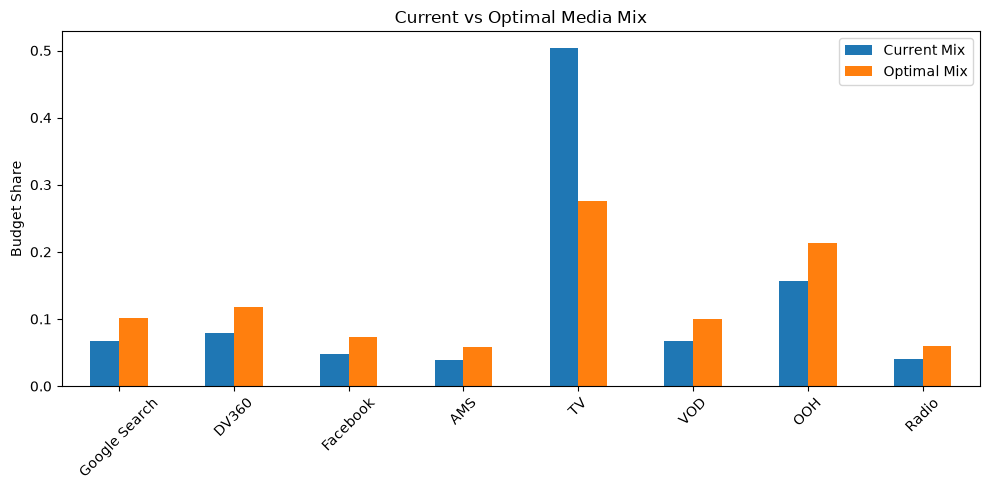

In [39]:
optimal = optimal_allocation.to_series()

comparison = pd.DataFrame({
    "Current Spend ($)": current * SPEND_UNIT,
    "Optimal Spend ($)": optimal * SPEND_UNIT,
    "Current Mix": current / budget,
    "Optimal Mix": optimal / optimal.sum(),
})

display(
    comparison.style.format({
        "Current Spend ($)": "${:,.0f}",
        "Optimal Spend ($)": "${:,.0f}",
        "Current Mix": "{:.1%}",
        "Optimal Mix": "{:.1%}",
    })
)

comparison[["Current Mix", "Optimal Mix"]].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.ylabel("Budget Share")
plt.title("Current vs Optimal Media Mix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
current_samples = optimizer.sample_response_distribution(
    allocation_strategy=current_allocation
)

optimal_samples = optimizer.sample_response_distribution(
    allocation_strategy=optimal_allocation
)

def expected_revenue(samples):
    y = samples["y"]
    sample_dims = [d for d in ["chain", "draw", "sample"] if d in y.dims]

    return (
        y.sum("date")
        .median(dim=sample_dims)
        .item()
        * REVENUE_UNIT
    )

current_revenue = expected_revenue(current_samples)
optimal_revenue = expected_revenue(optimal_samples)

uplift = optimal_revenue / current_revenue - 1

print(f"Current mix expected revenue: ${current_revenue:,.0f}")
print(f"Optimal mix expected revenue: ${optimal_revenue:,.0f}")
print(f"Expected uplift: {uplift:.2%}")

Sampling: [y]
Sampling: [y]


Current mix expected revenue: $7,172,046
Optimal mix expected revenue: $7,956,742
Expected uplift: 10.94%
